## Carga de modelo entrenado

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# PyTorch 
import torch
import torch.nn as nn
import torch.nn.functional as F

sns.set_theme(style="whitegrid", palette="pastel")


In [44]:
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f'GPU disponible: {torch.cuda.get_device_name(0)}')
else:
    device = torch.device('cpu')
print(f'Dispositivo seleccionado: {device}')

GPU disponible: NVIDIA RTX A2000 Laptop GPU
Dispositivo seleccionado: cuda


## Imágenes

In [45]:
from get_images import get_images

In [46]:
def normalise(x_mean, x_std, x_data):
    return (x_data - x_mean) / x_std

In [47]:
# MNIST path
mnist_path = '../data/mnist'

x_train_num, y_train_num, x_test_num, y_test_num = get_images(mnist_path)

x_train = x_train_num[:50000].reshape(50000, -1).astype(np.float32)
y_train = y_train_num[:50000].reshape(50000, 1)

x_test = x_test_num.copy().reshape(10000, -1).astype(np.float32)
y_test = y_test_num.copy().reshape(10000, 1)

x_mean = x_train.mean()
x_std = x_train.std()

x_test = normalise(x_mean, x_std, x_test)



In [49]:
def plot_number(image):
    plt.figure(figsize=(5,5))
    plt.imshow(image.squeeze(), cmap=plt.get_cmap('gray'))
    plt.axis('off')
    plt.show()

## Carga Modelo (solo pesos)

In [50]:
model_path = '../models/modelMNIST.pth'

In [51]:
hidden1 = 200
hidden = 200
modelMNIST = nn.Sequential(nn.Linear(in_features=784, out_features=hidden1), nn.ReLU(),
                       nn.Linear(in_features=hidden1, out_features=hidden), nn.ReLU(),
                       nn.Linear(in_features=hidden, out_features=10))

In [52]:
modelMNIST.load_state_dict(torch.load(model_path))

<All keys matched successfully>

In [53]:
modelMNIST = modelMNIST.to(device = 'cuda')
modelMNIST.eval()

Sequential(
  (0): Linear(in_features=784, out_features=200, bias=True)
  (1): ReLU()
  (2): Linear(in_features=200, out_features=200, bias=True)
  (3): ReLU()
  (4): Linear(in_features=200, out_features=10, bias=True)
)

In [54]:
def sample_image():
    rnd_idx = np.random.randint(10000)
    image = x_test[rnd_idx].reshape(1, 28, 28)
    plot_number(image)
    return torch.tensor(image).to(device='cuda', dtype=torch.float32).view(1, 784)
    

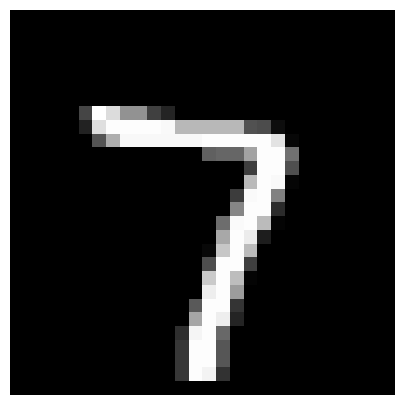

El num es: 7


In [55]:
image = sample_image()
_, pred = modelMNIST(image).max(1)
print(f'El num es: {pred[0]}')

## Carga Modelo (completo)

In [56]:
model_completo_path = '../models/modelMNIST_completo.pth'

In [57]:
# Cargar el modelo completo guardado
# weights_only=False porque confiamos en nuestro propio modelo guardado
modelMNIST_completo = torch.load(model_completo_path, map_location=device, weights_only=False)
modelMNIST_completo.eval()
modelMNIST_completo.to(device)

print("Modelo completo cargado exitosamente")
print(f"  Dispositivo: {device}")
print(f"  Ubicación: {model_completo_path}")

Modelo completo cargado exitosamente
  Dispositivo: cuda
  Ubicación: ../models/modelMNIST_completo.pth


### Probar con una imagen aleatoria

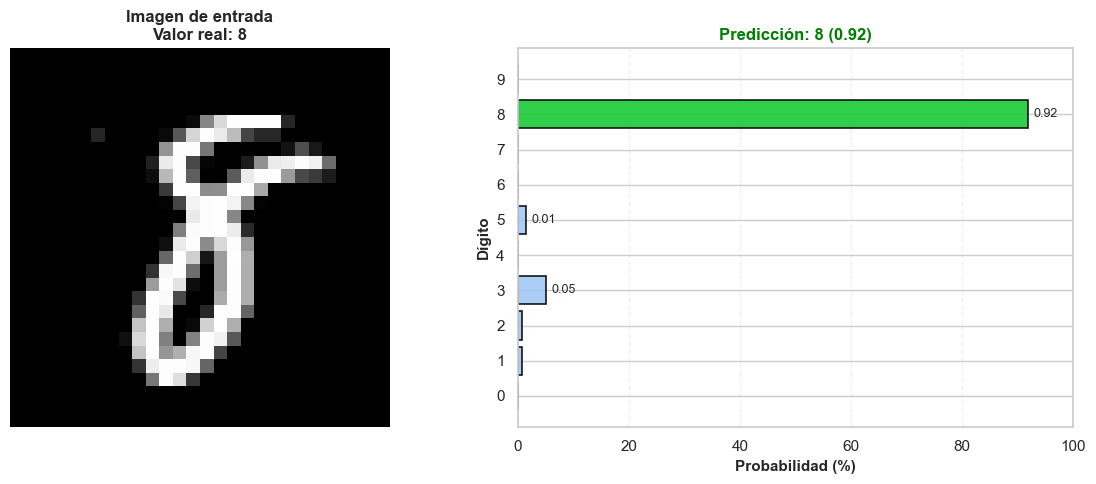

In [ ]:
# Seleccionar imagen aleatoria
idx = np.random.randint(len(y_test))
image = x_test[idx].reshape(1, 28, 28)
image_tensor = torch.tensor(image).to(device=device, dtype=torch.float32).view(1, 784)

# Predecir con el modelo cargado
modelMNIST_completo.eval()
with torch.no_grad():
    output = modelMNIST_completo(image_tensor)
    pred = output.argmax(dim=1).item()
    probs = F.softmax(output, dim=1)[0].cpu().numpy()

# Crear figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1: Imagen
ax1.imshow(x_test_num[idx].squeeze(), cmap='gray')
ax1.axis('off')
ax1.set_title(f'Imagen de entrada\nValor real: {y_test[idx, 0]}', 
             fontsize=12, fontweight='bold')

# Subplot 2: Barras horizontales de probabilidades
digits = np.arange(10)
colors = [sns.color_palette('bright')[2] if i == pred else sns.color_palette('pastel')[0] for i in digits]
bars = ax2.barh(digits, probs * 100, color=colors, alpha=0.9, edgecolor='black', linewidth=1.2)

# Etiquetas y formato
ax2.set_xlabel('Probabilidad (%)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Dígito', fontsize=11, fontweight='bold')
ax2.set_title(f'Predicción: {pred} ({probs[pred]:.2f})', 
             fontsize=12, fontweight='bold', color='green' if pred == y_test[idx, 0] else 'red')
ax2.set_yticks(digits)
ax2.set_xlim(0, 100)
ax2.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, prob) in enumerate(zip(bars, probs)):
    width = bar.get_width()
    if width > 1:  # Solo mostrar si es > 1% 
        ax2.text(width + 1, bar.get_y() + bar.get_height()/2, 
                f'{prob:.2f}',
                ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()